# Robot Failure / Maintenance Prediction

Extends **Final_Project_Group_1** (robot data streaming, DB persistence,
rule-based anomaly alerts) with a learned binary classifier: for each
reading, predict `at_risk` (0/1) **with a confidence score**, instead of
a hand-set per-axis threshold rule.

Each pipeline stage below is its own class, run in its own cell(s), matching
`RobotPM_MLOps.ipynb`'s module breakdown: `DataExtractionAnalysis` ->
`DataPreparation` -> `ModelTraining` (using `ModelSelection`'s classifiers)
-> `ModelEvaluationValidation` -> `TrainedMLModel`.

## 1. Load configuration

In [12]:
import sys, os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import ExperimentConfig
from configs.config import ExperimentConfig

config = ExperimentConfig.from_yaml("configs/experiment_config.yaml")
print("CSV source:", config.data["csv_path"])
print("Labeling settings:", config.labeling)
print("Model candidates:", config.model["candidates"])

CSV source: data/raw/robot_data.csv
Labeling settings: {'running_threshold': 0.5, 'baseline_fraction': 0.4, 'rolling_window': 5}
Model candidates: ['scratch', 'sklearn']


## 2. `DataExtractionAnalysis` — load, validate, profile

In [13]:
from src.data_extraction_analysis import DataExtractionAnalysis

extractor = DataExtractionAnalysis(config)
raw_df = extractor.extract()
print(raw_df.shape)
raw_df.head()

INFO:DataExtractionAnalysis:Data source type: csv
INFO:DataExtractionAnalysis:Loaded 39672 rows from data\raw\robot_data.csv
INFO:DataExtractionAnalysis:Profiled 39672 rows across 14 axes


(39672, 16)


,Trait,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Axis #9,Axis #10,Axis #11,Axis #12,Axis #13,Axis #14,Time
0,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17 12:18:23.660000+00:00
1,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17 12:18:25.472000+00:00
2,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17 12:18:27.348000+00:00
3,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17 12:18:29.222000+00:00
4,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17 12:18:31.117000+00:00


In [14]:
profile = extractor.profile(raw_df)
print("Rows:", profile["rows"])
print("Time range:", profile["time_range"])
print("Missing values per axis:", profile["missing_values"])

INFO:DataExtractionAnalysis:Profiled 39672 rows across 14 axes


Rows: 39672
Time range: (Timestamp('2022-10-17 12:18:23.660000+0000', tz='UTC'), Timestamp('2022-10-18 10:44:58.628000+0000', tz='UTC'))
Missing values per axis: {'Axis #1': 0, 'Axis #2': 0, 'Axis #3': 0, 'Axis #4': 0, 'Axis #5': 0, 'Axis #6': 0, 'Axis #7': 0, 'Axis #8': 0, 'Axis #9': 39672, 'Axis #10': 39672, 'Axis #11': 39672, 'Axis #12': 39672, 'Axis #13': 39672, 'Axis #14': 39672}


### Alternate source: the Neon database (`DataExtractionAnalysis.load_database()`)

Requires a `.env` with `DATABASE_URL` set;
skipped here since this environment has no live DB connection - set
`data.source_type: database` in the config to use it for real.

In [15]:
try:
    db_config = ExperimentConfig.from_yaml("configs/experiment_config.yaml")
    db_config.raw["data"]["source_type"] = "database"
    db_extractor = DataExtractionAnalysis(db_config)
    db_df = db_extractor.load_database()
    print(db_df.head())
except Exception as exc:
    print(f"Skipped (no live DB connection in this environment): {exc}")

Database connected successfully.
39672 record(s) retrieved from Neon.
Skipped (no live DB connection in this environment): time data "2022-10-17 12:39:34" doesn't match format "%Y-%m-%d %H:%M:%S.%f". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.


## 3. `DataPreparation` — state, alert, label, features, split, scale

Each step is callable on its own; `.run()` chains all of them.

In [16]:
from src.data_preparation import DataPreparation

preparer = DataPreparation.from_config(config)

df = preparer.compute_state(raw_df)
df = preparer.compute_alert(df)
df = preparer.add_label(df)

print("State counts:\n", df["State"].value_counts())
print("\nAlert counts:\n", df["Alert"].value_counts())
print(f"\nat_risk rate: {df['at_risk'].mean():.1%}")

State counts:
 State
STOPPED    25625
RUNNING    14047
Name: count, dtype: int64

Alert counts:
 Alert
NORMAL     39664
WARNING        8
Name: count, dtype: int64

at_risk rate: 0.0%


In [17]:
split = preparer.run(raw_df)  # full pipeline, incl. rolling features + chronological split + scaling
print("Features used:", split.feature_names)
print("Train:", split.X_train.shape, " Test:", split.X_test.shape)
print("at_risk in test set:", int(split.y_test.sum()), "/", len(split.y_test))

Features used: ['Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis #7', 'Axis #8', 'Total', 'Axis #1_roll_mean', 'Axis #1_roll_std', 'Axis #2_roll_mean', 'Axis #2_roll_std', 'Axis #3_roll_mean', 'Axis #3_roll_std', 'Axis #4_roll_mean', 'Axis #4_roll_std', 'Axis #5_roll_mean', 'Axis #5_roll_std', 'Axis #6_roll_mean', 'Axis #6_roll_std', 'Axis #7_roll_mean', 'Axis #7_roll_std', 'Axis #8_roll_mean', 'Axis #8_roll_std']
Train: (31737, 25)  Test: (7935, 25)
at_risk in test set: 4 / 7935


## 4. `ModelSelection` + `ModelTraining` — scratch logistic regression vs. scikit-learn

Both share the same `.fit()` / `.predict_proba()` interface, so the confidence score comes from either one identically.

In [18]:
from src.model_training import ModelTraining

trainer = ModelTraining.from_config(config)
fitted_models = trainer.train(split)
for name, model in fitted_models.items():
    print(name, "trained.")

From scratch (logistic) trained.
Scikit-learn (logistic) trained.


theta_0=-4.8898
Final training loss: 0.02096


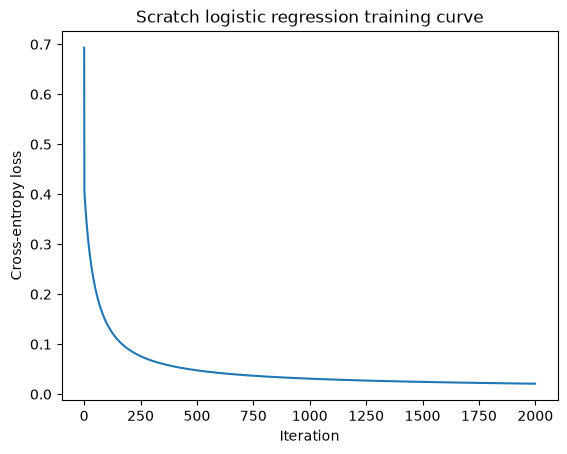

In [19]:
scratch_model = fitted_models["From scratch (logistic)"]
print(f"theta_0={scratch_model.theta_0:.4f}")
print("Final training loss:", round(scratch_model.cost_history[-1], 5))

import matplotlib.pyplot as plt
plt.plot(scratch_model.cost_history)
plt.xlabel("Iteration"); plt.ylabel("Cross-entropy loss"); plt.title("Scratch logistic regression training curve")
plt.show()

## 5. `ModelEvaluationValidation` — metrics, confidence, plots, experiment logging

In [20]:
from src.model_evaluation_validation import ModelEvaluationValidation

evaluator = ModelEvaluationValidation(threshold=config.model.get("threshold", 0.5))

fitted_probas = {name: model.predict_proba(split.X_test) for name, model in fitted_models.items()}
results = [evaluator.compute_metrics(name, split.y_test, proba) for name, proba in fitted_probas.items()]
comparison = evaluator.compare(results)
comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Mean_Confidence,Threshold
0,From scratch (logistic),0.9878,0.0206,0.5,0.0396,0.698,0.0288,0.5
1,Scikit-learn (logistic),0.9991,0.2857,0.5,0.3636,0.897,0.0012,0.5


C:\Users\KING\AppData\Local\Temp\ipykernel_18484\888729526.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


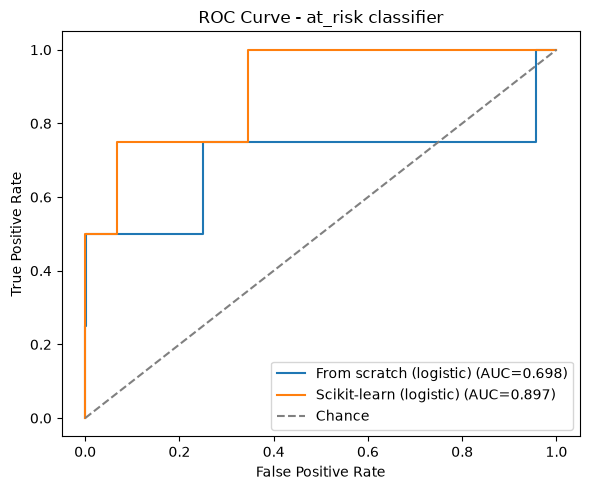

In [21]:
fig = evaluator.plot_roc(fitted_probas, split.y_test)
fig.show()

C:\Users\KING\AppData\Local\Temp\ipykernel_18484\2290195569.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


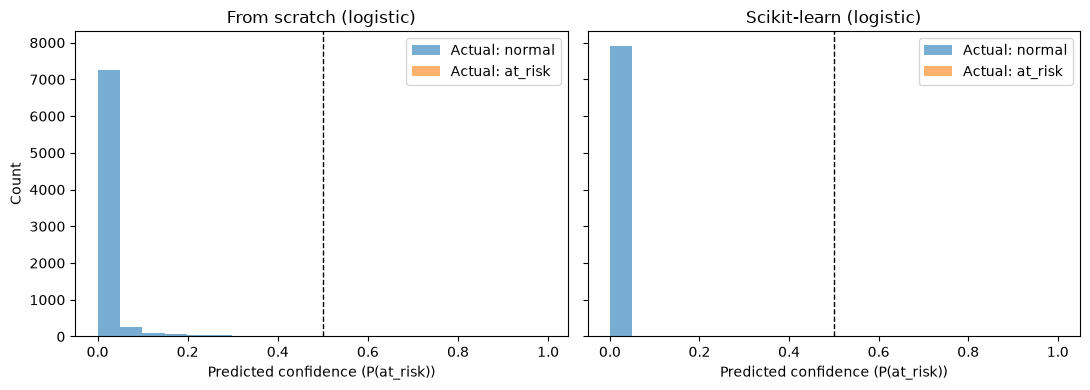

In [22]:
fig = evaluator.plot_confidence_distribution(fitted_probas, split.y_test)
fig.show()

C:\Users\KING\AppData\Local\Temp\ipykernel_18484\82877142.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Best model by ROC-AUC: Scikit-learn (logistic)


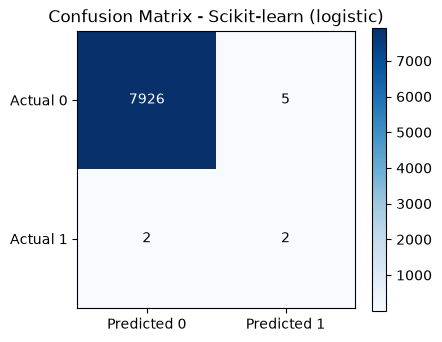

In [23]:
best_name = comparison.sort_values("ROC_AUC", ascending=False).iloc[0]["Model"]
fig = evaluator.plot_confusion(split.y_test, fitted_probas[best_name], best_name)
fig.show()
print("Best model by ROC-AUC:", best_name)

In [24]:
logged = evaluator.save_results(results, config.robot_results_path, append=True)
logged.tail()

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Mean_Confidence,Threshold
0,From scratch (logistic),0.987776,0.020619,0.5,0.039604,0.697957,0.028827,0.5
1,Scikit-learn (logistic),0.999118,0.285714,0.5,0.363636,0.896987,0.001152,0.5


## 6. `TrainedMLModel` — the deployable artifact

Bundles the winning model + scaler + feature order so a caller only needs raw axis readings.

In [25]:
from src.trained_ml_model import TrainedMLModel

best_model = fitted_models[best_name]
artifact = TrainedMLModel(
    model=best_model,
    scaler=preparer.scaler,
    feature_names=split.feature_names,
    threshold=config.model.get("threshold", 0.5),
    metadata={"selected_model": best_name},
)
artifact.save(config.artifact_path)
print("Saved to", config.artifact_path)

Saved to models/robot_failure_model.joblib


In [26]:
reloaded = TrainedMLModel.load(config.artifact_path)

sample = split.test_df.head(5)
predictions = reloaded.predict_with_confidence(sample)
for (_, row), pred in zip(sample.iterrows(), predictions):
    print(f"{row['Time']}  actual={row['at_risk']}  predicted={pred['at_risk']}  confidence={pred['confidence']:.3f}")

2022-10-18 06:18:18.955000+00:00  actual=0  predicted=0  confidence=0.000
2022-10-18 06:18:20.805000+00:00  actual=0  predicted=0  confidence=0.000
2022-10-18 06:18:22.637000+00:00  actual=0  predicted=0  confidence=0.000
2022-10-18 06:18:24.518000+00:00  actual=0  predicted=0  confidence=0.000
2022-10-18 06:18:26.363000+00:00  actual=0  predicted=0  confidence=0.000


## 7. Same pipeline via the CLI orchestrator

using `Orchestrator_main.py` we chained every stage above behind two commands, so training/scoring doesn't require opening a notebook:

```bash
python Orchestrator_main.py --mode train   --config configs/experiment_config.yaml
python Orchestrator_main.py --mode predict --config configs/experiment_config.yaml --data-csv data/raw/new_readings.csv
```